In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = pd.read_csv(
    r"C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\raw\soil_data.csv"
)

In [2]:
df.head()

,Sample_ID,District,Latitude,Longitude,Agro_Ecological_Zone,Soil_Order_Classification,pH,Nitrogen,Phosphorus,Potassium,Organic_Carbon,Sand,Clay,Silt
0,SL_SOIL_00001,Galle,6.065461,80.203629,Wet Zone,Ultisols,4.49,1.128,21.50,92.60,1.57,45.50,33.10,21.40
1,SL_SOIL_00002,Anuradhapura,8.272322,80.773659,Dry Zone,Alfisols,6.44,0.593,7.12,104.36,1.07,71.44,18.74,9.82
2,SL_SOIL_00003,Batticaloa,7.560748,81.380784,Dry Zone,Vertisols,6.46,0.913,10.33,144.44,1.35,56.04,17.67,26.30
3,SL_SOIL_00004,Kilinochchi,9.562287,80.478765,Dry Zone,Alfisols,6.47,0.881,13.47,159.32,0.99,59.92,26.60,13.48
4,SL_SOIL_00005,Matara,6.088399,80.500917,Wet Zone,Ultisols,5.59,1.015,13.27,119.35,1.13,53.81,31.79,14.40


In [3]:
df.shape

(5000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sample_ID                  5000 non-null   object 
 1   District                   5000 non-null   object 
 2   Latitude                   5000 non-null   float64
 3   Longitude                  5000 non-null   float64
 4   Agro_Ecological_Zone       5000 non-null   object 
 5   Soil_Order_Classification  5000 non-null   object 
 6   pH                         5000 non-null   float64
 7   Nitrogen                   5000 non-null   float64
 8   Phosphorus                 5000 non-null   float64
 9   Potassium                  5000 non-null   float64
 10  Organic_Carbon             5000 non-null   float64
 11  Sand                       5000 non-null   float64
 12  Clay                       5000 non-null   float64
 13  Silt                       5000 non-null   float

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sample_ID,5000,5000,SL_SOIL_00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,5000,25,Trincomalee,232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,5000.0,NaN,NaN,NaN,7.595063,1.022713,5.900759,6.883976,7.357112,8.287404,9.849819
Longitude,5000.0,NaN,NaN,NaN,80.590259,0.478818,79.701397,80.211135,80.593298,80.885852,81.894195
Agro_Ecological_Zone,5000,5,Dry Zone,2357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Soil_Order_Classification,5000,4,Alfisols,2371,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pH,5000.0,NaN,NaN,NaN,6.063328,0.801406,4.0,5.43,6.07,6.69,8.5
Nitrogen,5000.0,NaN,NaN,NaN,1.120882,0.315683,0.278,0.88,1.089,1.34,2.202
Phosphorus,5000.0,NaN,NaN,NaN,13.480724,4.613841,3.0,10.2975,13.36,16.59,29.64
Potassium,5000.0,NaN,NaN,NaN,135.500496,18.871811,76.55,122.12,134.73,148.3,198.04


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nFully duplicated rows:", df.duplicated().sum())
print("Duplicated Sample_IDs:", df['Sample_ID'].duplicated().sum())

Missing values per column:
Sample_ID                    0
District                     0
Latitude                     0
Longitude                    0
Agro_Ecological_Zone         0
Soil_Order_Classification    0
pH                           0
Nitrogen                     0
Phosphorus                   0
Potassium                    0
Organic_Carbon               0
Sand                         0
Clay                         0
Silt                         0
dtype: int64

Fully duplicated rows: 0
Duplicated Sample_IDs: 0


In [7]:
print(df['Sample_ID'].is_unique)
print(df['Sample_ID'].head().tolist())

True
['SL_SOIL_00001', 'SL_SOIL_00002', 'SL_SOIL_00003', 'SL_SOIL_00004', 'SL_SOIL_00005']


No missing values, no duplicate rows, and `Sample_ID` is a unique key for every
sample — this dataset needs no imputation or de-duplication.


### Geographic validity check

Coordinates outside Sri Lanka's bounding box: 0


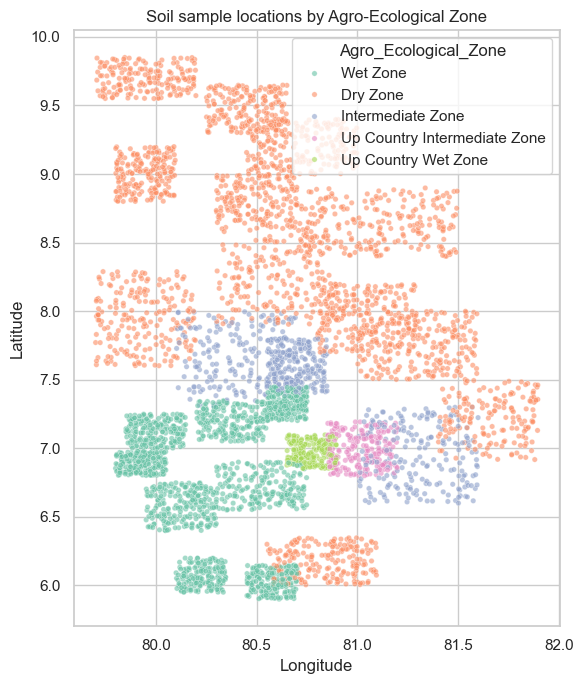

In [8]:
# Create output folder if it does not exist
import os

OUTPUT_DIR = r'C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\outputs\notebooks_task2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LAT_MIN, LAT_MAX = 5.9, 9.9
LON_MIN, LON_MAX = 79.6, 81.9

out_of_bounds = df[(df['Latitude'] < LAT_MIN) | (df['Latitude'] > LAT_MAX) |
                    (df['Longitude'] < LON_MIN) | (df['Longitude'] > LON_MAX)]
print(f"Coordinates outside Sri Lanka's bounding box: {len(out_of_bounds)}")

plt.figure(figsize=(6, 7))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='Agro_Ecological_Zone',
                 palette='Set2', s=15, alpha=0.6)
plt.title('Soil sample locations by Agro-Ecological Zone')
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, '06_soil_sample_locations.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

### Categorical field exploration

In [9]:
for col in ['District', 'Agro_Ecological_Zone', 'Soil_Order_Classification']:
    print(f"--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts())
    print()

--- District (25 unique) ---
District
Trincomalee     232
Batticaloa      216
Kalutara        216
Badulla         213
Polonnaruwa     213
Kandy           213
Matale          211
Monaragala      210
Matara          209
Mullaitivu      208
Kegalle         208
Gampaha         206
Colombo         205
Puttalam        203
Mannar          198
Ratnapura       198
Hambantota      198
Nuwara Eliya    195
Anuradhapura    189
Kurunegala      185
Vavuniya        180
Kilinochchi     179
Jaffna          178
Galle           174
Ampara          163
Name: count, dtype: int64

--- Agro_Ecological_Zone (5 unique) ---
Agro_Ecological_Zone
Dry Zone                        2357
Wet Zone                        1629
Intermediate Zone                606
Up Country Intermediate Zone     213
Up Country Wet Zone              195
Name: count, dtype: int64

--- Soil_Order_Classification (4 unique) ---
Soil_Order_Classification
Alfisols       2371
Ultisols       1629
Vertisols       592
Inceptisols     408
Name: count

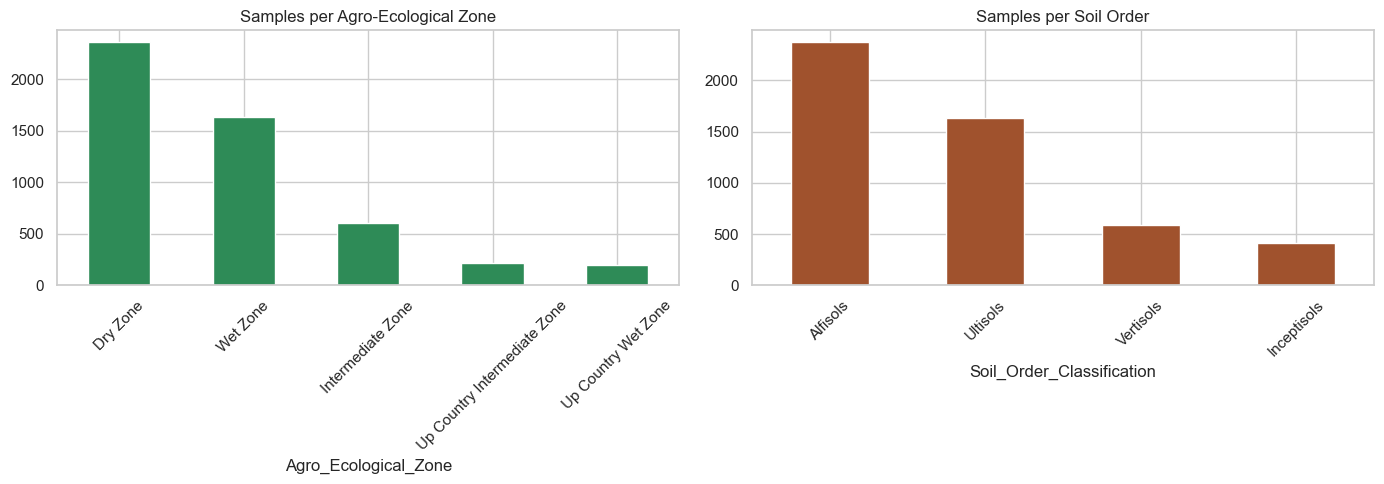

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['Agro_Ecological_Zone'].value_counts().plot(kind='bar', ax=axes[0], color='seagreen')
axes[0].set_title('Samples per Agro-Ecological Zone')
axes[0].tick_params(axis='x', rotation=45)

df['Soil_Order_Classification'].value_counts().plot(kind='bar', ax=axes[1], color='sienna')
axes[1].set_title('Samples per Soil Order')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, '07_soil_sample_distribution.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

### Numeric feature distributions

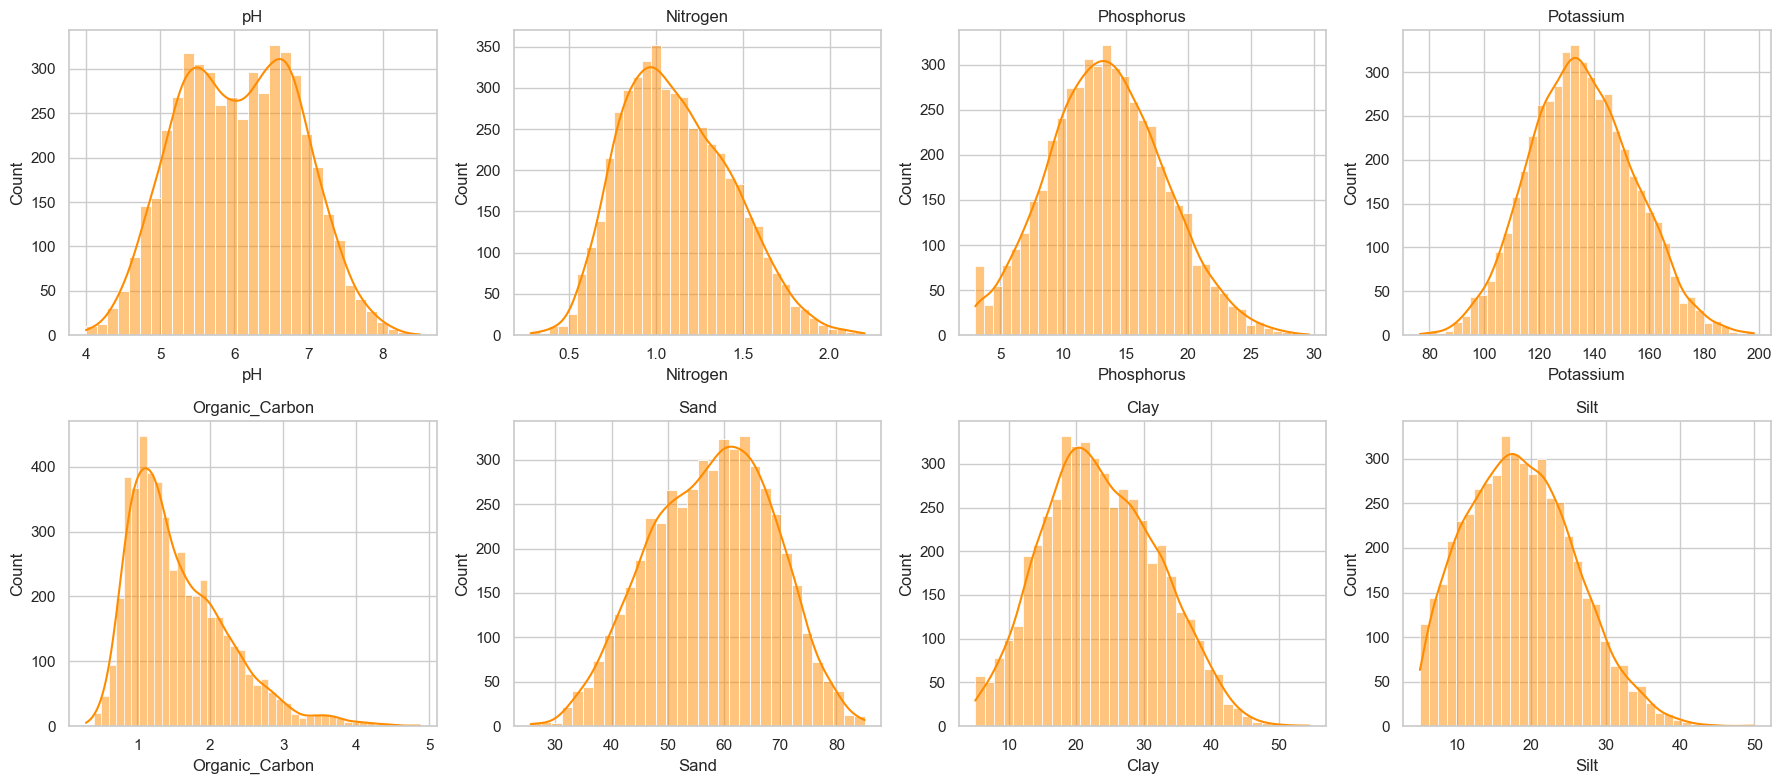

In [11]:
num_cols = ['pH', 'Nitrogen', 'Phosphorus', 'Potassium', 'Organic_Carbon',
            'Sand', 'Clay', 'Silt']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='darkorange')
    axes[i].set_title(col)
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, '08_soil_property_distributions.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

### Domain-specific validation: soil texture must sum to 100%

In [12]:
df['texture_sum'] = df['Sand'] + df['Clay'] + df['Silt']
print(df['texture_sum'].describe())

bad_texture = df[(df['texture_sum'] < 99.5) | (df['texture_sum'] > 100.5)]
print(f"\nRows where Sand+Clay+Silt is not ~100%: {len(bad_texture)}")

count    5000.000000
mean       99.999862
std         0.004964
min        99.990000
25%       100.000000
50%       100.000000
75%       100.000000
max       100.010000
Name: texture_sum, dtype: float64

Rows where Sand+Clay+Silt is not ~100%: 0


In [13]:
df = df.drop(columns='texture_sum')

### Outlier detection (IQR method)

In [14]:
def iqr_outlier_summary(data, cols):
    rows = []
    for col in cols:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((data[col] < lower) | (data[col] > upper)).sum()
        rows.append({'feature': col, 'lower_bound': round(lower, 2),
                     'upper_bound': round(upper, 2), 'n_outliers': n_out,
                     'pct_outliers': round(100 * n_out / len(data), 2)})
    return pd.DataFrame(rows)

outlier_summary = iqr_outlier_summary(df, num_cols)
outlier_summary

,feature,lower_bound,upper_bound,n_outliers,pct_outliers
0,pH,3.54,8.58,0,0.00
1,Nitrogen,0.19,2.03,17,0.34
2,Phosphorus,0.86,26.03,20,0.40
3,Potassium,82.85,187.57,24,0.48
4,Organic_Carbon,-0.27,3.29,117,2.34
5,Sand,25.97,89.84,2,0.04
6,Clay,-0.77,47.96,6,0.12
7,Silt,-2.74,39.37,17,0.34


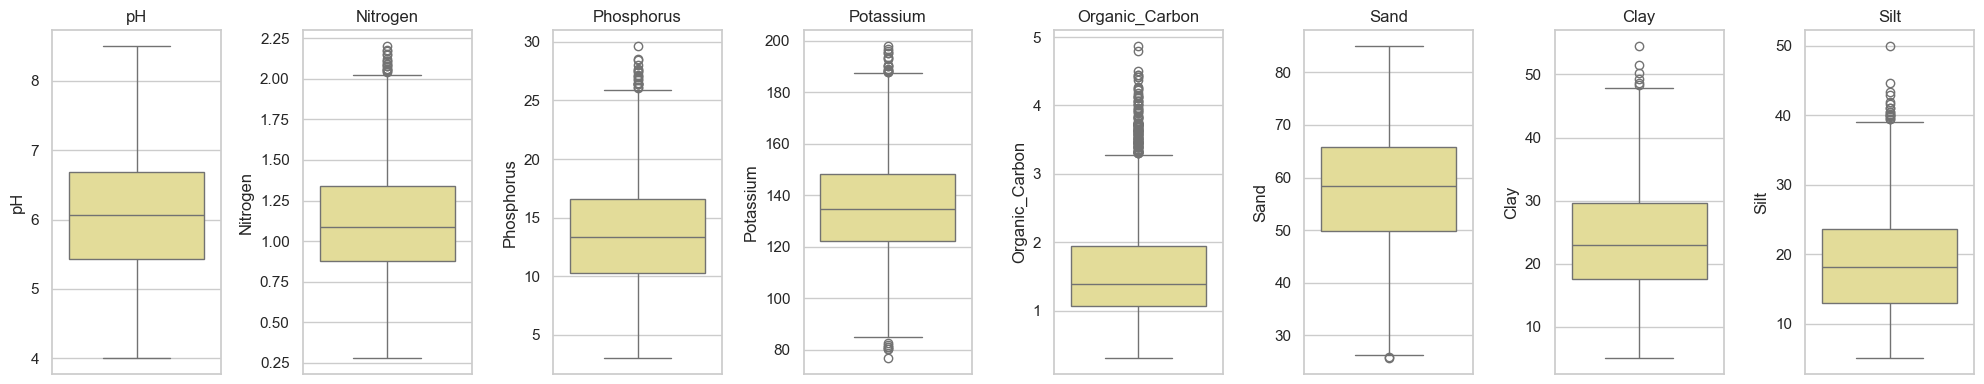

In [15]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='khaki')
    axes[i].set_title(col)
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, '09_soil_property_boxplots.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

In [17]:
q1, q3 = df['pH'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
ph_outliers = df[(df['pH'] < lower) | (df['pH'] > upper)]

print(ph_outliers['Agro_Ecological_Zone'].value_counts())
print()
print(ph_outliers['Soil_Order_Classification'].value_counts())

Series([], Name: count, dtype: int64)

Series([], Name: count, dtype: int64)


### Correlation between soil properties

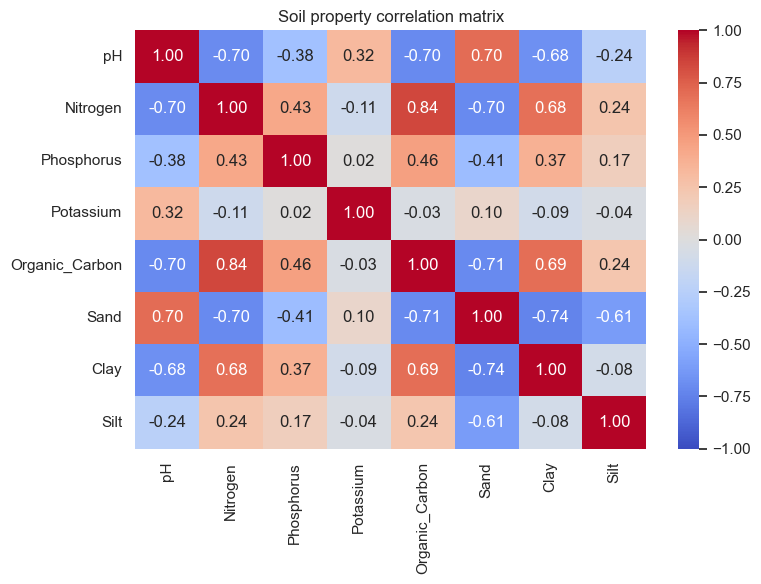

In [18]:
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Soil property correlation matrix')
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, '10_soil_property_correlation.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

### District-level aggregation

In [19]:
district_summary = df.groupby('District')[num_cols].mean().round(2)
district_summary

,pH,Nitrogen,Phosphorus,Potassium,Organic_Carbon,Sand,Clay,Silt
District,,,,,,,,
Ampara,6.45,1.08,14.79,144.99,1.41,57.22,24.60,18.18
Anuradhapura,6.30,0.86,11.43,124.47,1.01,67.45,16.18,16.38
Badulla,5.19,1.50,16.16,139.86,2.31,44.59,34.10,21.31
Batticaloa,6.83,1.01,13.73,149.88,1.32,60.17,21.84,17.99
Colombo,5.80,1.19,14.12,119.71,1.73,54.28,24.95,20.77
Galle,5.28,1.36,16.06,130.69,2.04,46.87,30.17,22.96
Gampaha,5.73,1.15,12.57,114.94,1.59,57.47,22.51,20.02
Hambantota,6.52,0.91,10.12,109.31,1.10,67.45,16.41,16.14
Jaffna,7.49,0.76,11.99,169.25,0.90,69.08,14.54,16.38


### Encoding categorical variables

In [20]:
df_encoded = pd.get_dummies(df, columns=['Agro_Ecological_Zone', 'Soil_Order_Classification'],
                             prefix=['AEZ', 'SoilOrder'])

le_district = LabelEncoder()
df_encoded['District_encoded'] = le_district.fit_transform(df['District'])

df_encoded.head()

,Sample_ID,District,Latitude,Longitude,pH,Nitrogen,Phosphorus,Potassium,Organic_Carbon,Sand,Clay,Silt,AEZ_Dry Zone,AEZ_Intermediate Zone,AEZ_Up Country Intermediate Zone,AEZ_Up Country Wet Zone,AEZ_Wet Zone,SoilOrder_Alfisols,SoilOrder_Inceptisols,SoilOrder_Ultisols,SoilOrder_Vertisols,District_encoded
0,SL_SOIL_00001,Galle,6.065461,80.203629,4.49,1.128,21.50,92.60,1.57,45.50,33.10,21.40,False,False,False,False,True,False,False,True,False,5
1,SL_SOIL_00002,Anuradhapura,8.272322,80.773659,6.44,0.593,7.12,104.36,1.07,71.44,18.74,9.82,True,False,False,False,False,True,False,False,False,1
2,SL_SOIL_00003,Batticaloa,7.560748,81.380784,6.46,0.913,10.33,144.44,1.35,56.04,17.67,26.30,True,False,False,False,False,False,False,False,True,3
3,SL_SOIL_00004,Kilinochchi,9.562287,80.478765,6.47,0.881,13.47,159.32,0.99,59.92,26.60,13.48,True,False,False,False,False,True,False,False,False,12
4,SL_SOIL_00005,Matara,6.088399,80.500917,5.59,1.015,13.27,119.35,1.13,53.81,31.79,14.40,False,False,False,False,True,False,False,True,False,16


### Feature scaling

In [21]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[num_cols])
df_scaled = df.copy()
df_scaled[[f'{c}_scaled' for c in num_cols]] = scaled_values

df_scaled[[c for c in df_scaled.columns if 'scaled' in c]].describe().T[['mean', 'std']]

,mean,std
pH_scaled,-3.417711e-16,1.0001
Nitrogen_scaled,2.010836e-16,1.0001
Phosphorus_scaled,2.977174e-16,1.0001
Potassium_scaled,8.384404e-17,1.0001
Organic_Carbon_scaled,5.577760e-17,1.0001
Sand_scaled,-9.663381e-17,1.0001
Clay_scaled,2.167155e-16,1.0001
Silt_scaled,3.218759e-16,1.0001


### Save processed outputs

In [22]:
import os

# Exact output folder for processed soil data
OUTPUT_DIR = r'C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\processed\soil_data'

# Create soil_data folder if it doesn't already exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save processed soil datasets
df.to_csv(
    os.path.join(OUTPUT_DIR, 'soil_data_clean.csv'),
    index=False
)

df_encoded.to_csv(
    os.path.join(OUTPUT_DIR, 'soil_data_encoded.csv'),
    index=False
)

df_scaled.to_csv(
    os.path.join(OUTPUT_DIR, 'soil_data_scaled.csv'),
    index=False
)

district_summary.to_csv(
    os.path.join(OUTPUT_DIR, 'soil_district_summary.csv')
)

# Show saved files
print("Saved files:")

for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.startswith('soil'):
        print(' -', f)

print("\nSaved successfully to:")
print(OUTPUT_DIR)

Saved files:
 - soil_data_clean.csv
 - soil_data_encoded.csv
 - soil_data_scaled.csv
 - soil_district_summary.csv

Saved successfully to:
C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\processed\soil_data
